# European Option Pricing Analysis

This notebook validates the Black–Scholes implementation for European calls and puts using a term-dependent yield curve. It checks baseline prices, put–call parity and the sensitivity of a call price to volatility.

Core pricing logic is contained in the reusable classes under `src/`; this notebook focuses on validation and interpretation.

## 1. Setup

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.yieldcurve import YieldCurve
from src.derivatives import EuropeanCall, EuropeanPut

## 2. Construct the yield curve

The following illustrative zero-rate curve provides the maturity-specific risk-free rate used by each option contract.

In [2]:
maturities = [0.5, 1.0, 2.0, 3.0]
zero_rates = [0.03, 0.032, 0.035, 0.038]

yield_curve = YieldCurve(maturities, zero_rates)

## 3. Inspect the interpolated term structure

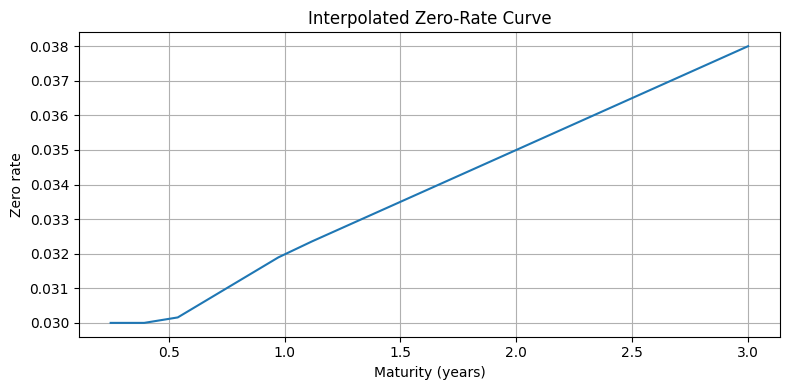

In [3]:
test_maturities = np.linspace(0.25, 3.0, 20)
rates = [yield_curve.get_zero_rate(T) for T in test_maturities]

plt.figure(figsize=(8, 4))
plt.plot(test_maturities, rates)
plt.title("Interpolated Zero-Rate Curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Zero rate")
plt.grid(True)
plt.tight_layout()
plt.show()

The curve rises gradually across the maturity range, so longer-dated cash flows are discounted using a higher continuously compounded zero rate.

## 4. Price an at-the-money call and put

In [4]:
S0 = 100.0
K = 100.0
T = 1.0
sigma = 0.20

call = EuropeanCall(S0, K, T, sigma, yield_curve)
put = EuropeanPut(S0, K, T, sigma, yield_curve)

call_price = call.price()
put_price = put.price()

print(f"Call price: {call_price:.4f}")
print(f"Put price:  {put_price:.4f}")

Call price: 9.5146
Put price:  6.3653


For an at-the-money option with one year to maturity and 20% volatility, the model produces a **call value of 9.5146** and a **put value of 6.3653**. The call is more valuable because the positive risk-free rate lowers the present value of the strike.

## 5. Validate put–call parity

In [5]:
discount_factor = yield_curve.get_discount_factor(T)
parity_error = call_price - put_price - (S0 - K * discount_factor)

print(f"Put-call parity error: {parity_error:.10f}")

Put-call parity error: 0.0000000000


The parity error is effectively zero, providing a direct consistency check across the call, put and discounting implementations.

## 6. Examine call-price sensitivity to volatility

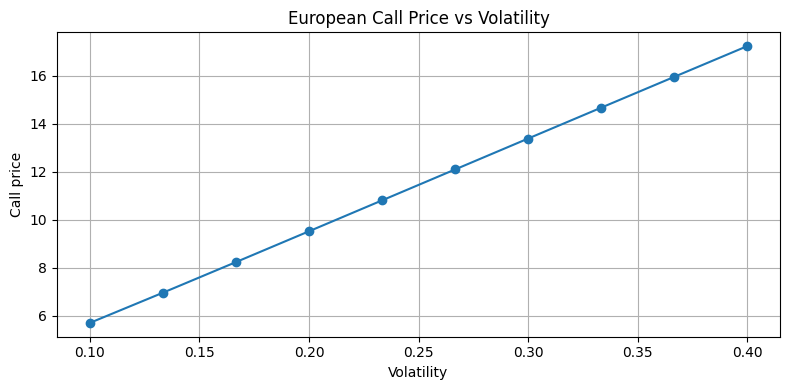

In [6]:
volatilities = np.linspace(0.10, 0.40, 10)
call_prices = [
    EuropeanCall(S0, K, T, vol, yield_curve).price()
    for vol in volatilities
]

plt.figure(figsize=(8, 4))
plt.plot(volatilities, call_prices, marker='o')
plt.title("European Call Price vs Volatility")
plt.xlabel("Volatility")
plt.ylabel("Call price")
plt.grid(True)
plt.tight_layout()
plt.show()

The call price increases monotonically as volatility rises. Greater dispersion increases the value of the option's asymmetric payoff while the holder's downside remains limited to the premium.

## 7. Findings

- The option classes integrate correctly with the interpolated yield curve.
- Baseline call and put prices satisfy put–call parity to numerical precision.
- Call values rise with volatility, consistent with the positive vega of a European option under Black–Scholes.

The next extension is to invert market option prices to estimate implied volatility and examine how it varies across strikes and maturities.